# DLSD rush routes — per-hour run counts

Explore how many **`analysis_ok`** DLSD runs exist per hour for rush-only routes **134, 135, 136, 143, 148**, compared to all-day **146, 147**.

Rush **plot targets** come from **weekday (Mon–Thu) counts** with **`n_runs >= 30`** (`MIN_RUNS_RUSH_WEEKDAY_ELIGIBILITY` / `valid_rush_plot_cells()`). **Friday** comparison plots reuse that target set (no separate Friday ≥30 gate). **Weekend** views show **146 and 147** only.

**Day slices** (match planned comparison views):
- `weekday`: Monday–Thursday (`day_of_week` 0–3)
- `friday`: Friday only
- `weekend`: Saturday–Sunday

Data: local `data/mansueto/trips_{pid}_last30d.parquet` via [`cache_dlsd_parquets.py`](../scripts/cache_dlsd_parquets.py).


In [1]:
%matplotlib inline

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

_nb = Path.cwd() if (Path.cwd() / "dlsd_run_quality.py").is_file() else Path.cwd() / "notebooks"
if str(_nb) not in sys.path:
    sys.path.insert(0, str(_nb))

from dlsd_run_quality import (
    ALL_DAY_DLSD_ROUTES,
    DEFAULT_PLOT_HOURS,
    MIN_RUNS_RUSH_WEEKDAY_ELIGIBILITY,
    routes_for_day_slice,
    valid_rush_plot_cells,
    RUSH_ROUTES,
    build_dlsd_runs,
    day_slice_mask,
    hour_run_counts,
    load_dlsd_boundaries,
)

REPO_ROOT = _nb.parent if _nb.name == "notebooks" else _nb
_style = REPO_ROOT / "notebooks" / "cta_analysis.mplstyle"
if _style.is_file():
    plt.style.use(_style)

DAY_SLICES = ["weekday", "friday", "weekend"]
PLOT_HOURS = DEFAULT_PLOT_HOURS


In [2]:
boundaries = load_dlsd_boundaries()
dlsd_runs = build_dlsd_runs(boundaries, prefer_local=True)
dlsd_runs = dlsd_runs.loc[dlsd_runs["analysis_ok"]].copy()
print(f"analysis_ok runs: {len(dlsd_runs):,}")
print(
    "entry_time range:",
    dlsd_runs["entry_time"].min(),
    "→",
    dlsd_runs["entry_time"].max(),
)


analysis_ok runs: 14,734
entry_time range: 2026-06-27 09:33:11.153005721 → 2026-07-28 00:28:39.585857208


In [3]:
all_counts = []
for slice_name in DAY_SLICES:
    rush = hour_run_counts(dlsd_runs, routes=RUSH_ROUTES, day_slice=slice_name)
    all_day = hour_run_counts(dlsd_runs, routes=ALL_DAY_DLSD_ROUTES, day_slice=slice_name)
    all_counts.append(rush)
    all_counts.append(all_day)
counts_df = pd.concat(all_counts, ignore_index=True)
display(counts_df.sort_values(["day_slice", "route", "rtdir", "hour"]).head(20))


,route,rtdir,hour,n_runs,day_slice
133,134,Northbound,16,17,friday
134,134,Northbound,17,19,friday
135,134,Northbound,18,8,friday
136,134,Southbound,5,1,friday
137,134,Southbound,6,14,friday
138,134,Southbound,7,34,friday
139,134,Southbound,8,27,friday
140,134,Southbound,9,7,friday
141,135,Northbound,12,1,friday
142,135,Northbound,14,2,friday


In [4]:
def pivot_counts(sub: pd.DataFrame) -> pd.DataFrame:
    return sub.pivot_table(
        index=["route", "rtdir"],
        columns="hour",
        values="n_runs",
        fill_value=0,
        aggfunc="sum",
    ).reindex(columns=PLOT_HOURS, fill_value=0)

for slice_name in DAY_SLICES:
    sub = counts_df[counts_df["day_slice"] == slice_name]
    print(f"\n=== {slice_name} — runs per hour (rows with any service) ===")
    display(pivot_counts(sub))



=== weekday — runs per hour (rows with any service) ===


hour               6    7    8    9    10  11  12   13   14   15   16   17  \
route rtdir                                                                  
134   Northbound    0    0    0    0    0   0   0    0    0    2   99  100   
      Southbound   82  176  164   48    0   0   0    0    0    0    0    0   
135   Northbound    0    0    0    0    0   0   1    0    2   43   84  102   
      Southbound   81  168  115   62    5   0   0    0    0    0    0    0   
136   Northbound    0    0    0    0    0   0   1    0    0    1   79   81   
      Southbound   79   84   39   42    0   0   0    0    0    0    0    0   
143   Northbound    0    0    0    0    0   0   0    0    0    0   44  108   
      Southbound   32  116  158   16    0   0   0    0    0    0    0    0   
146   Northbound   44   68   73   81   90  88  80  101   77   92  101  158   
      Southbound   94  166  185  135  125  95  92   82   98   83   92   56   
147   Northbound   46   45   52   50   48  67  79   77  103  124  155  180   
      Southbound  129  193  130  119   95  79  78   78   81   86   66   51   
148   Northbound    0    0    0    0    0   0   0    0    0   31   66  112   
      Southbound   60  154  131   62    0   0   0    0    0    0    0    0   

hour               18   19   20  21  22  
route rtdir                              
134   Northbound   51    2    0   0   0  
      Southbound    0    0    0   0   0  
135   Northbound   82   20    0   0   1  
      Southbound    0    0    0   0   0  
136   Northbound   62   12    0   0   0  
      Southbound    0    0    0   0   0  
143   Northbound   79    3    0   0   0  
      Southbound    0    0    0   0   0  
146   Northbound  175  150  118  97  95  
      Southbound   49   62   64  65  58  
147   Northbound  140   98   98  84  68  
      Southbound   47   48   48  52  50  
148   Northbound   78    9    0   1   0  
      Southbound    0    0    0   0   0


=== friday — runs per hour (rows with any service) ===


hour              6   7   8   9   10  11  12  13  14  15  16  17  18  19  20  \
route rtdir                                                                    
134   Northbound   0   0   0   0   0   0   0   0   0   0  17  19   8   0   0   
      Southbound  14  34  27   7   0   0   0   0   0   0   0   0   0   0   0   
135   Northbound   0   0   0   0   0   0   1   0   2   3  10  14   7   6   0   
      Southbound  12  32  18  10   0   0   0   0   0   0   0   0   0   0   0   
136   Northbound   0   0   0   0   0   0   0   0   0   1  14  12  12   3   0   
      Southbound  14  15   7   7   0   0   0   0   0   0   0   0   0   0   0   
143   Northbound   0   0   0   0   0   0   0   0   0   0   7  18  13   2   0   
      Southbound   5  22  25   3   0   0   0   0   0   0   0   0   0   0   0   
146   Northbound   7  13  14  16  15  18  20  20  16  11  28  25  28  29  25   
      Southbound  17  33  34  31  25  23  21  15  22  15  24  12  17   9   8   
147   Northbound   6  11  15  12   8  17  17  18  20  25  38  37  25  19  19   
      Southbound  29  39  27  26  21  16  19  22  15  18  16  13  15  11   8   
148   Northbound   0   0   0   0   0   0   0   0   0   7  17  14  13   0   0   
      Southbound  12  25  26   8   0   0   0   0   0   0   0   0   0   0   0   

hour              21  22  
route rtdir               
134   Northbound   0   0  
      Southbound   0   0  
135   Northbound   0   0  
      Southbound   0   0  
136   Northbound   0   0  
      Southbound   0   0  
143   Northbound   0   0  
      Southbound   0   0  
146   Northbound  22  15  
      Southbound  14  13  
147   Northbound  17  15  
      Southbound  13  10  
148   Northbound   0   0  
      Southbound   0   0


=== weekend — runs per hour (rows with any service) ===


hour              6   7   8   9   10  11  12  13  14  15  16  17  18  19  20  \
route rtdir                                                                    
146   Northbound   0  17  27  25  29  29  33  51  58  52  53  56  51  62  60   
      Southbound  28  30  50  54  60  56  57  55  59  58  51  50  40  22  23   
147   Northbound  13  28  24  30  28  37  37  45  44  52  49  54  52  43  36   
      Southbound  32  42  52  50  57  54  51  49  55  50  46  47  46  36  30   

hour              21  22  
route rtdir               
146   Northbound  33  32  
      Southbound  29  22  
147   Northbound  37  27  
      Southbound  30  21

In [5]:
summary_rows = []
for slice_name in DAY_SLICES:
    sub = counts_df[counts_df["day_slice"] == slice_name]
    for route in sorted(RUSH_ROUTES | ALL_DAY_DLSD_ROUTES):
        rs = sub[sub["route"] == route]
        if rs.empty:
            continue
        positive = rs.loc[rs["n_runs"] > 0, "n_runs"]
        summary_rows.append(
            {
                "day_slice": slice_name,
                "route": route,
                "hours_with_data": (rs["n_runs"] > 0).sum(),
                "min_n_positive_hour": int(positive.min()) if len(positive) else 0,
                "median_n_positive_hour": float(positive.median()) if len(positive) else 0.0,
                "max_n_positive_hour": int(positive.max()) if len(positive) else 0,
            }
        )
summary_df = pd.DataFrame(summary_rows)
display(summary_df.sort_values(["day_slice", "route"]))


,day_slice,route,hours_with_data,min_n_positive_hour,median_n_positive_hour,max_n_positive_hour
7,friday,134,8,1,15.5,34
8,friday,135,12,1,8.5,32
9,friday,136,9,1,12.0,15
10,friday,143,8,2,10.0,25
11,friday,146,37,5,17.0,34
12,friday,147,41,1,16.0,39
13,friday,148,8,7,13.5,26
0,weekday,134,9,2,82.0,176
1,weekday,135,14,1,52.5,168
2,weekday,136,10,1,52.0,84


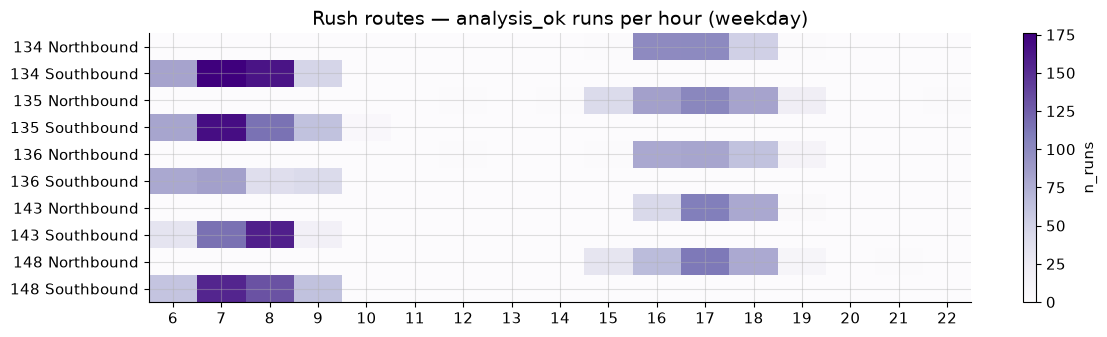

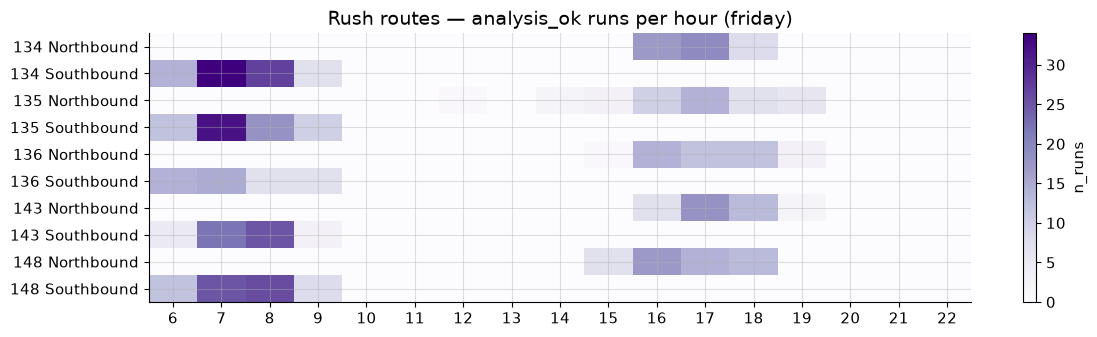

In [6]:
for slice_name in DAY_SLICES:
    sub = counts_df[(counts_df["day_slice"] == slice_name) & (counts_df["route"].isin(RUSH_ROUTES))]
    if sub.empty:
        continue
    pivot = pivot_counts(sub)
    fig, ax = plt.subplots(figsize=(12, max(3, 0.35 * len(pivot))))
    im = ax.imshow(pivot.values, aspect="auto", cmap="Purples")
    ax.set_yticks(range(len(pivot.index)), labels=[f"{r} {d}" for r, d in pivot.index])
    ax.set_xticks(range(len(PLOT_HOURS)), labels=PLOT_HOURS)
    ax.set_title(f"Rush routes — analysis_ok runs per hour ({slice_name})")
    fig.colorbar(im, ax=ax, label="n_runs")
    fig.tight_layout()
    plt.show()


## Valid rush plot targets (weekday ≥30)

Eligibility uses **Monday–Thursday** `analysis_ok` counts only. Comparison plots pass `valid_cells=valid_rush_plot_cells(dlsd_runs)` into `hour_dlsd_stats` for rush routes.

- **Weekday pane:** stats from Mon–Thu runs; series only at valid targets.
- **Friday pane:** stats from Friday runs; **same** valid targets (Friday `n_runs` may be &lt;30).
- **Weekend pane:** routes `routes_for_day_slice("weekend")` → 146/147 only (no rush gate).


In [7]:
valid_cells = valid_rush_plot_cells(dlsd_runs)
print(
    f"MIN_RUNS_RUSH_WEEKDAY_ELIGIBILITY: {MIN_RUNS_RUSH_WEEKDAY_ELIGIBILITY}"
)
print(f"Valid rush plot cells (weekday): {len(valid_cells)}")
display(valid_cells.sort_values(["route", "rtdir", "hour"]).reset_index(drop=True))

friday_counts = hour_run_counts(dlsd_runs, routes=RUSH_ROUTES, day_slice="friday")
contrast = valid_cells.merge(
    friday_counts[["route", "rtdir", "hour", "n_runs"]].rename(
        columns={"n_runs": "friday_n_runs"}
    ),
    on=["route", "rtdir", "hour"],
    how="left",
)
contrast["friday_n_runs"] = contrast["friday_n_runs"].fillna(0).astype(int)
print("Weekday-eligible targets vs Friday run counts (same cells):")
display(
    contrast.sort_values(["route", "rtdir", "hour"]).rename(
        columns={"n_runs": "weekday_n_runs"}
    )
)
below = contrast.loc[contrast["friday_n_runs"] < MIN_RUNS_RUSH_WEEKDAY_ELIGIBILITY]
print(
    f"Targets where Friday n_runs < {MIN_RUNS_RUSH_WEEKDAY_ELIGIBILITY}: {len(below)}"
)


MIN_RUNS_RUSH_WEEKDAY_ELIGIBILITY: 30
Valid rush plot cells (weekday): 36


,route,rtdir,hour,n_runs
0,134,Northbound,16,99
1,134,Northbound,17,100
2,134,Northbound,18,51
3,134,Southbound,6,82
4,134,Southbound,7,176
5,134,Southbound,8,164
6,134,Southbound,9,48
7,135,Northbound,15,43
8,135,Northbound,16,84
9,135,Northbound,17,102


Weekday-eligible targets vs Friday run counts (same cells):


,route,rtdir,hour,weekday_n_runs,friday_n_runs
0,134,Northbound,16,99,17
1,134,Northbound,17,100,19
2,134,Northbound,18,51,8
3,134,Southbound,6,82,14
4,134,Southbound,7,176,34
5,134,Southbound,8,164,27
6,134,Southbound,9,48,7
7,135,Northbound,15,43,3
8,135,Northbound,16,84,10
9,135,Northbound,17,102,14


Targets where Friday n_runs < 30: 34
